In [1]:
# ============================================================
# TBM-X — 08 PROPULSION MODEL
# ============================================================
#
# Objective:
# Build a systematic turboprop propulsion model
# and connect it directly to the aerodynamic model.
#
# Main components:
#   1. Engine rated power
#   2. Altitude power correction
#   3. Propeller efficiency
#   4. BSFC
#   5. Available shaft power
#   6. Required shaft power from aerodynamics
#   7. Power margin
#   8. Fuel flow
#
# Philosophy:
# Raymer + Physics + Benchmark + Engineering Assumptions
#
# Important:
# This is still a conceptual-level propulsion model.
# It is NOT a detailed thermodynamic engine model..
# ============================================================

**LIBRAIRIES**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

**WORKING DIRECTORY**

In [3]:
# ------------------------------------------------------------
# Project root
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd()

print("Current working directory:")
print(PROJECT_ROOT)

Current working directory:
C:\Users\musta\Documents\RAYMER\TBM-X_v0.2_data_engineering


**Connect to the 07 Aerodynamic Model**

In [4]:
# ============================================================
# INPUTS FROM 07 — AERODYNAMIC MODEL
# ============================================================

MTOW_kg = 3400.0

wing_area_m2 = 18.0
aspect_ratio = 9.15

cruise_speed_kt = 300.0
cruise_altitude_ft = 25000.0

# Required shaft power calculated by aerodynamic model
# Initial value for connection test
required_shaft_power_kW = 650.0

print(f"MTOW: {MTOW_kg:.1f} kg")
print(f"Wing area: {wing_area_m2:.2f} m²")
print(f"Cruise speed: {cruise_speed_kt:.1f} kt")
print(f"Cruise altitude: {cruise_altitude_ft:.0f} ft")
print(f"Required shaft power: {required_shaft_power_kW:.1f} kW")

MTOW: 3400.0 kg
Wing area: 18.00 m²
Cruise speed: 300.0 kt
Cruise altitude: 25000 ft
Required shaft power: 650.0 kW


**Unit conversions**

In [5]:
# ------------------------------------------------------------
# Unit conversions
# ------------------------------------------------------------

FT_TO_M = 0.3048
KT_TO_MS = 0.514444

cruise_altitude_m = cruise_altitude_ft * FT_TO_M
cruise_speed_m_s = cruise_speed_kt * KT_TO_MS

print(f"Altitude: {cruise_altitude_m:.1f} m")
print(f"Speed: {cruise_speed_m_s:.2f} m/s")

Altitude: 7620.0 m
Speed: 154.33 m/s


**ISA ATMOSPHERE**

In [6]:
# ============================================================
# ISA ATMOSPHERE
# ============================================================

def isa_atmosphere(altitude_m):
    """
    Simplified ISA atmosphere model.

    Valid here for the troposphere:
        h <= 11 km

    Returns:
        Temperature [K]
        Pressure [Pa]
        Density [kg/m³]
    """

    T0 = 288.15
    P0 = 101325.0

    lapse_rate = 0.0065
    R = 287.05
    g = 9.80665

    T = T0 - lapse_rate * altitude_m

    P = P0 * (
        T / T0
    ) ** (
        g / (R * lapse_rate)
    )

    rho = P / (R * T)

    return T, P, rho

**Cruise Atmosphere**

In [7]:
T_cruise, P_cruise, rho_cruise = isa_atmosphere(
    cruise_altitude_m
)

print(f"Temperature : {T_cruise:.2f} K")
print(f"Pressure    : {P_cruise:.0f} Pa")
print(f"Density     : {rho_cruise:.4f} kg/m³")

Temperature : 238.62 K
Pressure    : 37601 Pa
Density     : 0.5489 kg/m³


**Standard Sea-Level Density**

In [8]:
# ------------------------------------------------------------
# Standard sea-level density
# ------------------------------------------------------------

rho_sl = 1.225  # kg/m³

sigma = rho_cruise / rho_sl

print(f"Density ratio σ = {sigma:.4f}")

Density ratio σ = 0.4481


**Engine Rated Power**

In [9]:
# ============================================================
# ENGINE MODEL
# ============================================================

# Conceptual engine rated power
engine_rated_power_kW = 650.0

print(
    f"Engine rated power: "
    f"{engine_rated_power_kW:.1f} kW"
)

Engine rated power: 650.0 kW


**Engine Power Class**

In [10]:
KW_TO_SHP = 1.34102209

engine_rated_power_shp = (
    engine_rated_power_kW * KW_TO_SHP
)

print(
    f"Rated power: "
    f"{engine_rated_power_shp:.1f} shp"
)

Rated power: 871.7 shp


**Altitude Power Correction**

In [11]:
# ============================================================
# ENGINE ALTITUDE MODEL
# ============================================================

def altitude_power_factor(
    density_ratio,
    critical_altitude_ratio=0.40,
    exponent=0.70
):
    """
    Simplified conceptual altitude power model.

    Below the critical altitude:
        power ≈ rated power

    Above the critical altitude:
        power decreases with density ratio.

    This is NOT a detailed PT6 thermodynamic model.
    It is a conceptual engineering approximation.
    """

    if density_ratio >= critical_altitude_ratio:
        return 1.0

    factor = (
        density_ratio /
        critical_altitude_ratio
    ) ** exponent

    return factor

**Calculate Altitude Power Factor**

In [12]:
power_factor = altitude_power_factor(
    sigma
)

print(
    f"Altitude power factor: "
    f"{power_factor:.3f}"
)

Altitude power factor: 1.000


**Available Engine Shaft Power**

In [13]:
# ============================================================
# AVAILABLE SHAFT POWER
# ============================================================

available_engine_power_kW = (
    engine_rated_power_kW *
    power_factor
)

print(
    f"Available engine shaft power "
    f"at {cruise_altitude_ft:.0f} ft: "
    f"{available_engine_power_kW:.1f} kW"
)

Available engine shaft power at 25000 ft: 650.0 kW


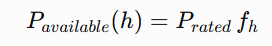

**Propeller Efficiency**

In [14]:
# ============================================================
# PROPELLER MODEL
# ============================================================

propeller_efficiency = 0.85

print(
    f"Propeller efficiency ηp = "
    f"{propeller_efficiency:.2f}"
)

Propeller efficiency ηp = 0.85


**Propulsive Power Available**

In [15]:
# ------------------------------------------------------------
# Propulsive power available to the aircraft
# ------------------------------------------------------------

available_propulsive_power_kW = (
    available_engine_power_kW *
    propeller_efficiency
)

print(
    f"Available propulsive power: "
    f"{available_propulsive_power_kW:.1f} kW"
)

Available propulsive power: 552.5 kW


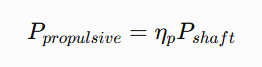

**Required Power from Aerodynamics**

In [16]:
# ============================================================
# REQUIRED POWER FROM AERODYNAMICS
# ============================================================

P_required_kW = required_shaft_power_kW

print(
    f"Required shaft power from 07: "
    f"{P_required_kW:.1f} kW"
)

Required shaft power from 07: 650.0 kW


**Power Margin**

In [17]:
# ============================================================
# POWER MARGIN
# ============================================================

power_margin_kW = (
    available_engine_power_kW -
    P_required_kW
)

power_margin_fraction = (
    power_margin_kW /
    P_required_kW
)

print(f"Available shaft power : {available_engine_power_kW:.1f} kW")
print(f"Required shaft power  : {P_required_kW:.1f} kW")
print(f"Power margin           : {power_margin_kW:.1f} kW")
print(f"Margin fraction        : {power_margin_fraction:.1%}")

Available shaft power : 650.0 kW
Required shaft power  : 650.0 kW
Power margin           : 0.0 kW
Margin fraction        : 0.0%


**Propeller-Level Check**

In [18]:
# ============================================================
# PROPULSION POWER CONSISTENCY CHECK
# ============================================================

required_propulsive_power_kW = (
    P_required_kW *
    propeller_efficiency
)

print(
    f"Required shaft power       : "
    f"{P_required_kW:.1f} kW"
)

print(
    f"Equivalent propulsive power: "
    f"{required_propulsive_power_kW:.1f} kW"
)

Required shaft power       : 650.0 kW
Equivalent propulsive power: 552.5 kW


**BSFC — BRAKE SPECIFIC FUEL CONSUMPTION**

In [19]:
# ============================================================
# BSFC — BRAKE SPECIFIC FUEL CONSUMPTION
# ============================================================

BSFC_kg_kWh = 0.30

print(
    f"BSFC = {BSFC_kg_kWh:.3f} kg/kWh"
)

BSFC = 0.300 kg/kWh


**Fuel Flow**

In [20]:
# ============================================================
# FUEL FLOW
# ============================================================

fuel_flow_kg_h = (
    BSFC_kg_kWh *
    P_required_kW
)

print(
    f"Estimated fuel flow: "
    f"{fuel_flow_kg_h:.1f} kg/h"
)

Estimated fuel flow: 195.0 kg/h


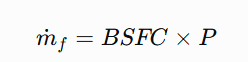

**Fuel Flow at Maximum Available Power**

In [21]:
# ------------------------------------------------------------
# Fuel flow at available engine power
# ------------------------------------------------------------

fuel_flow_max_kg_h = (
    BSFC_kg_kWh *
    available_engine_power_kW
)

print(
    f"Fuel flow at available power: "
    f"{fuel_flow_max_kg_h:.1f} kg/h"
)

Fuel flow at available power: 195.0 kg/h


**Engine Load**

In [22]:
# ============================================================
# ENGINE LOAD
# ============================================================

engine_load_fraction = (
    P_required_kW /
    available_engine_power_kW
)

print(
    f"Engine load: "
    f"{engine_load_fraction:.1%}"
)

Engine load: 100.0%


**Power Balance Summary**

In [23]:
# ============================================================
# POWER BALANCE
# ============================================================

propulsion_summary = pd.DataFrame({
    "Parameter": [
        "Engine rated power",
        "Altitude power factor",
        "Available engine shaft power",
        "Propeller efficiency",
        "Available propulsive power",
        "Required shaft power",
        "Power margin",
        "Engine load",
        "BSFC",
        "Fuel flow"
    ],
    
    "Value": [
        engine_rated_power_kW,
        power_factor,
        available_engine_power_kW,
        propeller_efficiency,
        available_propulsive_power_kW,
        P_required_kW,
        power_margin_kW,
        engine_load_fraction,
        BSFC_kg_kWh,
        fuel_flow_kg_h
    ],
    
    "Unit": [
        "kW",
        "-",
        "kW",
        "-",
        "kW",
        "kW",
        "kW",
        "-",
        "kg/kWh",
        "kg/h"
    ]
})

propulsion_summary

,Parameter,Value,Unit
0,Engine rated power,650.00,kW
1,Altitude power factor,1.00,-
2,Available engine shaft power,650.00,kW
3,Propeller efficiency,0.85,-
4,Available propulsive power,552.50,kW
5,Required shaft power,650.00,kW
6,Power margin,0.00,kW
7,Engine load,1.00,-
8,BSFC,0.30,kg/kWh
9,Fuel flow,195.00,kg/h


**Provenance Table**

In [24]:
# ============================================================
# PARAMETER PROVENANCE
# ============================================================

provenance = pd.DataFrame({
    "Parameter": [
        "Engine rated power",
        "Altitude power model",
        "Propeller efficiency",
        "BSFC",
        "Required shaft power",
        "Atmospheric density"
    ],
    
    "Source_Type": [
        "BENCHMARK / ENGINE DATA",
        "ENGINEERING ASSUMPTION",
        "ENGINEERING ASSUMPTION",
        "ENGINEERING ASSUMPTION",
        "PHYSICS MODEL — 07",
        "ISA PHYSICS MODEL"
    ],
    
    "Status": [
        "Preliminary",
        "Preliminary",
        "Preliminary",
        "Preliminary",
        "Calculated",
        "Calculated"
    ]
})

provenance

,Parameter,Source_Type,Status
0,Engine rated power,BENCHMARK / ENGINE DATA,Preliminary
1,Altitude power model,ENGINEERING ASSUMPTION,Preliminary
2,Propeller efficiency,ENGINEERING ASSUMPTION,Preliminary
3,BSFC,ENGINEERING ASSUMPTION,Preliminary
4,Required shaft power,PHYSICS MODEL — 07,Calculated
5,Atmospheric density,ISA PHYSICS MODEL,Calculated


**Altitude Sweep**

In [25]:
# ============================================================
# ALTITUDE POWER SWEEP
# ============================================================

altitudes_ft = np.linspace(
    0,
    35000,
    100
)

altitudes_m = (
    altitudes_ft *
    FT_TO_M
)

density_ratios = []

available_powers_kW = []

for altitude_m in altitudes_m:
    
    T, P, rho = isa_atmosphere(
        altitude_m
    )
    
    sigma_i = rho / rho_sl
    
    factor_i = altitude_power_factor(
        sigma_i
    )
    
    power_i = (
        engine_rated_power_kW *
        factor_i
    )
    
    density_ratios.append(
        sigma_i
    )
    
    available_powers_kW.append(
        power_i
    )

available_powers_kW = np.array(
    available_powers_kW
)

**Required vs Available Power**

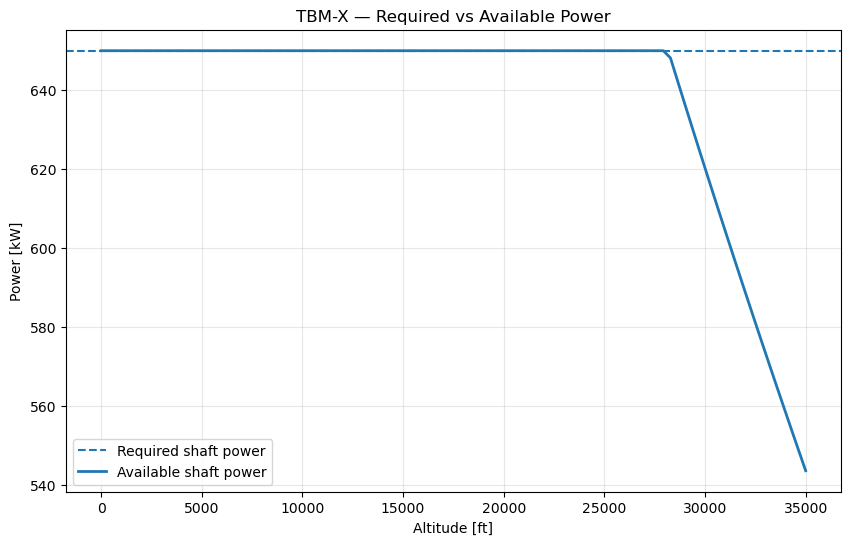

In [26]:
plt.figure(figsize=(10, 6))

plt.axhline(
    P_required_kW,
    linestyle="--",
    label="Required shaft power"
)

plt.plot(
    altitudes_ft,
    available_powers_kW,
    linewidth=2,
    label="Available shaft power"
)

plt.xlabel("Altitude [ft]")
plt.ylabel("Power [kW]")
plt.title("TBM-X — Required vs Available Power")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

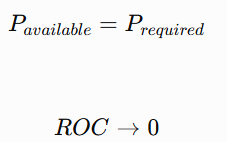

**PROPELLER EFFICIENCY SENSITIVITY**

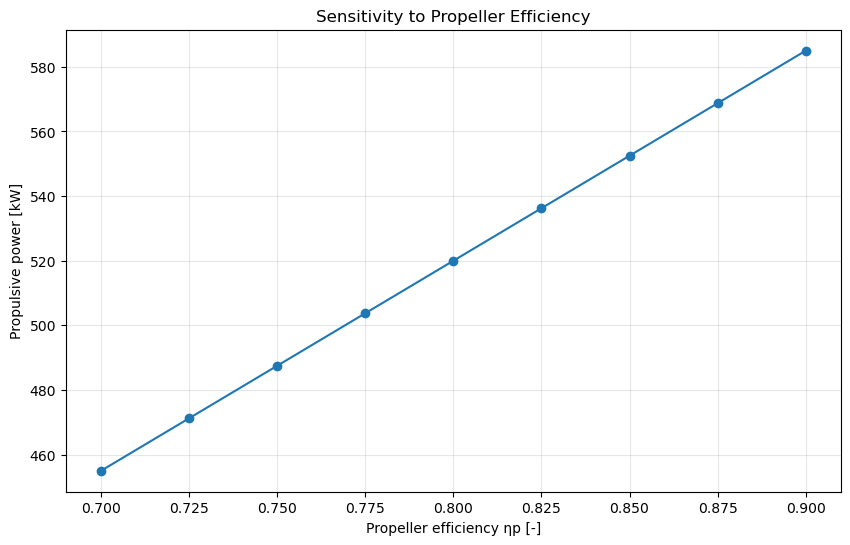

In [27]:
# ============================================================
# PROPELLER EFFICIENCY SENSITIVITY
# ============================================================

eta_values = np.linspace(
    0.70,
    0.90,
    9
)

propulsive_powers = (
    available_engine_power_kW *
    eta_values
)

plt.figure(figsize=(10, 6))

plt.plot(
    eta_values,
    propulsive_powers,
    marker="o"
)

plt.xlabel("Propeller efficiency ηp [-]")
plt.ylabel("Propulsive power [kW]")
plt.title("Sensitivity to Propeller Efficiency")

plt.grid(True, alpha=0.3)

plt.show()

**BSFC Sensitivity**

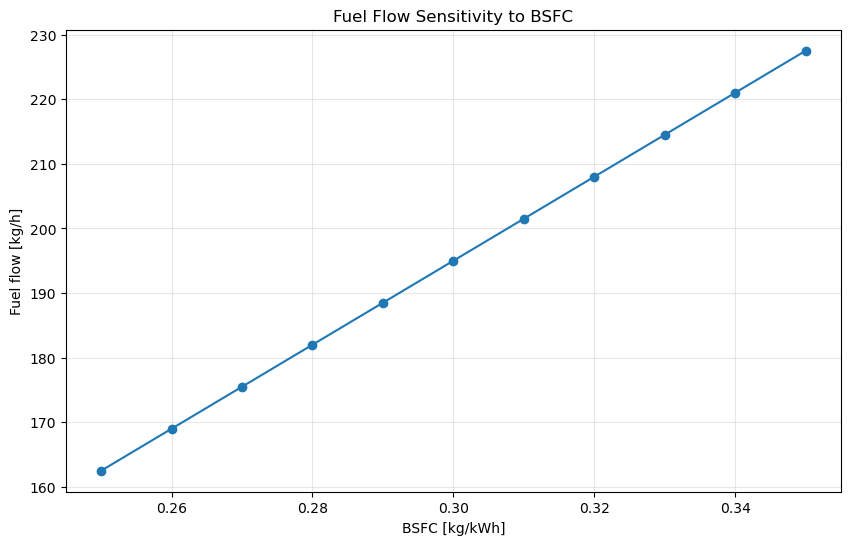

In [28]:
# ============================================================
# BSFC SENSITIVITY
# ============================================================

BSFC_values = np.linspace(
    0.25,
    0.35,
    11
)

fuel_flows = (
    BSFC_values *
    P_required_kW
)

plt.figure(figsize=(10, 6))

plt.plot(
    BSFC_values,
    fuel_flows,
    marker="o"
)

plt.xlabel("BSFC [kg/kWh]")
plt.ylabel("Fuel flow [kg/h]")
plt.title("Fuel Flow Sensitivity to BSFC")

plt.grid(True, alpha=0.3)

plt.show()

**Propulsion Sanity Checks**

In [29]:
# ============================================================
# ENGINEERING SANITY CHECKS
# ============================================================

print("=== PROPULSION SANITY CHECKS ===")

if engine_rated_power_kW > 0:
    print("✓ Engine rated power is positive.")
else:
    print("✗ Invalid engine power.")

if 0 < propeller_efficiency <= 1:
    print("✓ Propeller efficiency is physically valid.")
else:
    print("✗ Invalid propeller efficiency.")

if BSFC_kg_kWh > 0:
    print("✓ BSFC is positive.")
else:
    print("✗ Invalid BSFC.")

if available_engine_power_kW >= P_required_kW:
    print("✓ Required power can be satisfied.")
else:
    print("✗ Required power exceeds available power.")

if 0 < engine_load_fraction <= 1:
    print("✓ Engine load is within available power.")
else:
    print("⚠ Engine load exceeds available power.")

=== PROPULSION SANITY CHECKS ===
✓ Engine rated power is positive.
✓ Propeller efficiency is physically valid.
✓ BSFC is positive.
✓ Required power can be satisfied.
✓ Engine load is within available power.


**Final Propulsion Snapshot**

In [30]:
# ============================================================
# FINAL PROPULSION SNAPSHOT
# ============================================================

final_propulsion = pd.DataFrame({
    "Parameter": [
        "Cruise altitude",
        "Cruise speed",
        "Engine rated power",
        "Altitude power factor",
        "Available shaft power",
        "Propeller efficiency",
        "Required shaft power",
        "Power margin",
        "Engine load",
        "BSFC",
        "Fuel flow"
    ],
    
    "Value": [
        cruise_altitude_ft,
        cruise_speed_kt,
        engine_rated_power_kW,
        power_factor,
        available_engine_power_kW,
        propeller_efficiency,
        P_required_kW,
        power_margin_kW,
        engine_load_fraction,
        BSFC_kg_kWh,
        fuel_flow_kg_h
    ],
    
    "Unit": [
        "ft",
        "kt",
        "kW",
        "-",
        "kW",
        "-",
        "kW",
        "kW",
        "-",
        "kg/kWh",
        "kg/h"
    ]
})

final_propulsion

,Parameter,Value,Unit
0,Cruise altitude,25000.00,ft
1,Cruise speed,300.00,kt
2,Engine rated power,650.00,kW
3,Altitude power factor,1.00,-
4,Available shaft power,650.00,kW
5,Propeller efficiency,0.85,-
6,Required shaft power,650.00,kW
7,Power margin,0.00,kW
8,Engine load,1.00,-
9,BSFC,0.30,kg/kWh


**Save Results**

In [31]:
# ============================================================
# SAVE PROPULSION RESULTS
# ============================================================

output_dir = (
    PROJECT_ROOT /
    "outputs" /
    "propulsion"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_file = (
    output_dir /
    "TBM_X_propulsion_summary.csv"
)

final_propulsion.to_csv(
    output_file,
    index=False
)

print(f"Saved to:\n{output_file}")

Saved to:
C:\Users\musta\Documents\RAYMER\TBM-X_v0.2_data_engineering\outputs\propulsion\TBM_X_propulsion_summary.csv


**Final Engineering Statement**

In [32]:
# ============================================================
# FINAL ENGINEERING STATEMENT
# ============================================================

print("""
TBM-X PROPULSION MODEL — ENGINEERING SUMMARY
---------------------------------------------

The propulsion model is now connected conceptually
to the aerodynamic required-power model.

The model separates:

1. Engine rated shaft power
2. Altitude-dependent available shaft power
3. Propeller efficiency
4. Aircraft required shaft power
5. Power margin
6. Engine load
7. BSFC
8. Fuel flow

The current model is conceptual-level.

Engine altitude behaviour, propeller efficiency and BSFC
are still preliminary engineering assumptions and should
later be replaced or calibrated using reliable benchmark
or engine data.

The next objective is to connect this propulsion model
to aircraft performance and mission analysis.
""")


TBM-X PROPULSION MODEL — ENGINEERING SUMMARY
---------------------------------------------

The propulsion model is now connected conceptually
to the aerodynamic required-power model.

The model separates:

1. Engine rated shaft power
2. Altitude-dependent available shaft power
3. Propeller efficiency
4. Aircraft required shaft power
5. Power margin
6. Engine load
7. BSFC
8. Fuel flow

The current model is conceptual-level.

Engine altitude behaviour, propeller efficiency and BSFC
are still preliminary engineering assumptions and should
later be replaced or calibrated using reliable benchmark
or engine data.

The next objective is to connect this propulsion model
to aircraft performance and mission analysis.



                TBM-X
                  │
       ┌──────────┴──────────┐
       │                     │
   REQUIREMENTS          BENCHMARK
       │                     │
       └──────────┬──────────┘
                  │
             05 WEIGHT
                  │
                  ▼
             06 GEOMETRY
                  │
                  ▼
          07 AERODYNAMICS
                  │
          ┌───────┴────────┐
          │                │
     CD0 + CDi        Required Power
          │                │
          └───────┬────────┘
                  ▼
          08 PROPULSION
                  │
        ┌─────────┼──────────┐
        │         │          │
     Engine    Propeller   BSFC
      Power    Efficiency
        │         │          │
        └─────────┼──────────┘
                  │
                  ▼
          Available Power
                  │
                  ▼
          Power Margin
                  │
                  ▼
        09 PERFORMANCE
                  │
                  ▼
           10 MISSION